# HealthConnect – Initial Data Assessment
Week 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452", "#55A868"]

## Data Overview

In [2]:
df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")
df.shape

(5000, 18)

In [3]:
df.dtypes

appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object

In [14]:
df.head(10)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


## Missing Values and Duplicates

In [4]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [5]:
df.duplicated().sum(), df["appointment_id"].duplicated().sum()

(np.int64(0), np.int64(0))

In [6]:
df.loc[df["reminder_channel"].isnull(), "reminder_sent"].value_counts()

reminder_sent
No    1366
Name: count, dtype: int64

## Target Variable

In [7]:
df["appointment_outcome"].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

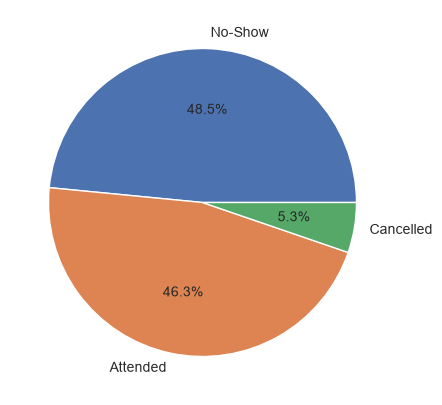

In [8]:
plt.figure()
df["appointment_outcome"].value_counts().plot.pie(autopct="%1.1f%%", colors=COLORS, ylabel="")
plt.savefig("../visuals/01_outcome_distribution.png", bbox_inches="tight")
plt.show()

## No-Show Rate by Key Variables

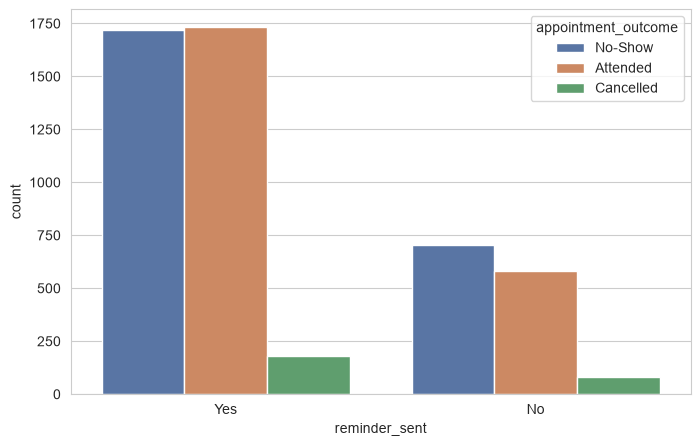

In [9]:
plt.figure()
sns.countplot(data=df, x="reminder_sent", hue="appointment_outcome", palette=COLORS)
plt.savefig("../visuals/02_outcome_by_reminder.png", bbox_inches="tight")
plt.show()

In [10]:
df.groupby("previous_no_shows")["appointment_outcome"].apply(lambda s: (s == "No-Show").mean()).head(10)

previous_no_shows
0    0.435125
1    0.534884
2    0.593607
3    0.679487
4    0.666667
5    1.000000
Name: appointment_outcome, dtype: float64

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_36112\3460945824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="appointment_outcome", y="distance_to_clinic_km", palette=COLORS)


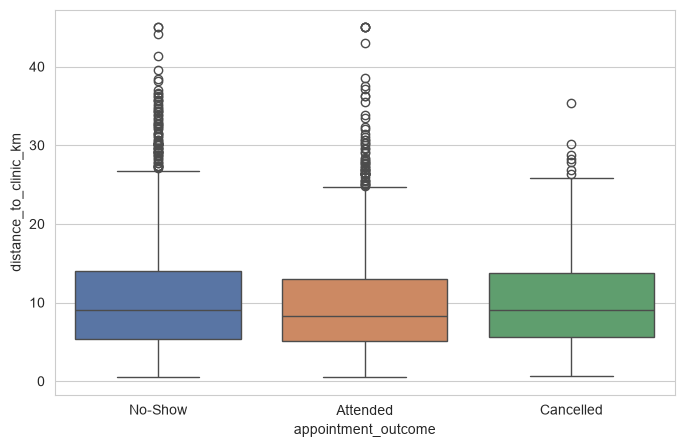

In [11]:
plt.figure()
sns.boxplot(data=df, x="appointment_outcome", y="distance_to_clinic_km", palette=COLORS)
plt.savefig("../visuals/03_distance_by_outcome.png", bbox_inches="tight")
plt.show()

## Data Quality Flag — waiting_time_minutes

In [12]:
df.groupby("appointment_outcome")["waiting_time_minutes"].describe()

,count,mean,std,min,25%,50%,75%,max
appointment_outcome,,,,,,,,
Attended,2293.0,24.289141,10.946389,2.0,17.0,24.0,32.0,68.0
Cancelled,261.0,23.214559,10.557896,2.0,16.0,22.0,29.0,55.0
No-Show,2386.0,24.200754,10.814945,2.0,17.0,24.0,31.0,67.0


## Categorical Frequencies

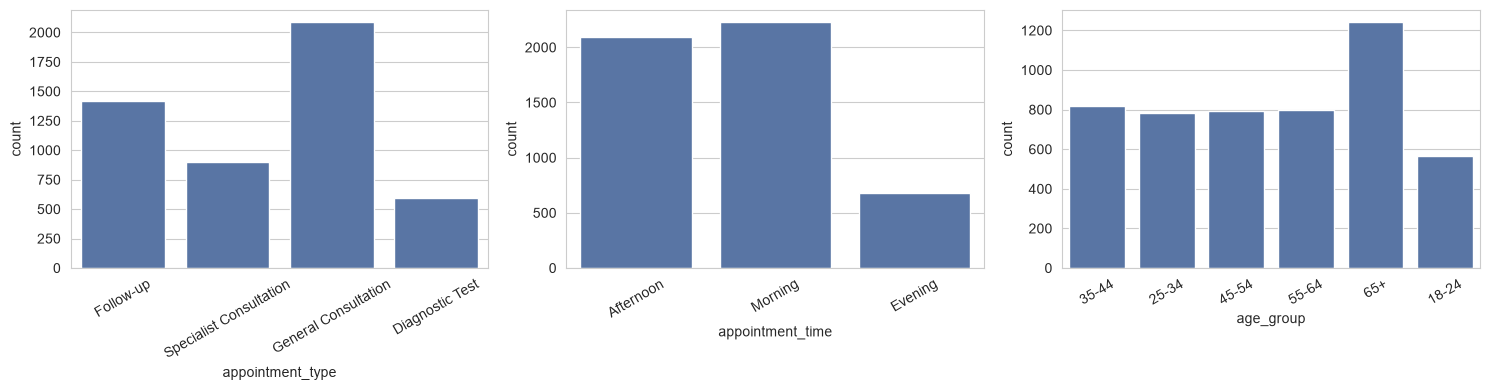

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="appointment_type", ax=axes[0], color=COLORS[0])
sns.countplot(data=df, x="appointment_time", ax=axes[1], color=COLORS[0])
sns.countplot(data=df, x="age_group", ax=axes[2], color=COLORS[0])
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../visuals/04_categorical_frequencies.png", bbox_inches="tight")
plt.show()